# __Auto Price Prediction__

## Feature Description

Here is a simple explanation of every column:

symboling           : Car risk level (from insurance rating). Higher = more risky<br>
normalized-losses	: Relative average loss per insured vehicle<br>
make	            : Brand (BMW, Toyota, Honda, etc.)<br>
fuel-type	        : gas or diesel<br>
aspiration	        : std or turbo<br>
num-of-doors	    : two or four<br>
body-style	        : sedan, hatchback, wagon, etc.<br>
drive-wheels	    : fwd, rwd, or 4wd<br>
engine-location	    : front or rear<br>
wheel-base	        : Distance between front & rear axles<br>
length	            : Car length<br>
width	            : Car width<br>
height	            : Car height<br>
curb-weight	        : Weight of the car without passengers<br>
engine-type	        : ohc, ohcv, dohc, etc.<br>
num-of-cylinders	: four, six, eight…<br>
engine-size	        : Size of engine in cc<br>
fuel-system	        : mpfi, 2bbl, idi, etc.<br>
bore	            : Cylinder bore size<br>
stroke	            : Piston stroke length<br>
compression-ratio	: Engine compression level<br>
horsepower	        : Engine power<br>
peak-rpm	        : Maximum RPM<br>
city-mpg	        : Mileage in city<br>
highway-mpg	        : Mileage on highway<br>
price	            : Target variable (car price in USD)

## Problem Description

The automobile industry relies heavily on accurate pricing to remain competitive and profitable.
Car prices depend on multiple factors such as engine specifications, fuel efficiency, size, brand, and design characteristics. Manually estimating prices is difficult because the relationships between these features and price are complex and often non-linear.<br>

This is a supervised regression problem, where the target variable is a continuous value (price).

# __Preparing the library__

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Preprocessing use
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # make pipline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, confusion_matrix

# Some Regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Importing the warnings so that our notebook looks more prettier
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set display option to show all columns
pd.set_option("display.max_columns",None)

In [4]:
# Load dataset
dataset = pd.read_csv("auto_imports.csv")

In [5]:
# Giving the columns name 
col_names = [
    "symboling","normalized_losses","make","fuel_type","aspiration",
    "num_of_doors","body_style","drive_wheels","engine_location",
    "wheel_base","length","width","height","curb_weight","engine_type",
    "num_of_cylinders","engine_size","fuel_system","bore","stroke",
    "compression_ratio","horsepower","peak_rpm","city_mpg",
    "highway_mpg","price"
]
dataset.columns = col_names

In [6]:
dataset.head() # Showing the first 5 row of dataset

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


In [7]:
dataset.tail() # Showing the last 5 row of dataset

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470
199,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3062,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


## Overview

In this project, the Auto Imports Dataset containing 205 car records and 26 attributes was used. The dataset includes a mix of numerical features (engine size, horsepower, mileage, dimensions) and categorical features (make, body style, fuel type, drive wheels).

## Basic Check

In [8]:
dataset.shape # It showing number of column and row

(200, 26)

In [9]:
dataset.info() # Showing the information of dataset 

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          200 non-null    int64  
 1   normalized_losses  200 non-null    str    
 2   make               200 non-null    str    
 3   fuel_type          200 non-null    str    
 4   aspiration         200 non-null    str    
 5   num_of_doors       200 non-null    str    
 6   body_style         200 non-null    str    
 7   drive_wheels       200 non-null    str    
 8   engine_location    200 non-null    str    
 9   wheel_base         200 non-null    float64
 10  length             200 non-null    float64
 11  width              200 non-null    float64
 12  height             200 non-null    float64
 13  curb_weight        200 non-null    int64  
 14  engine_type        200 non-null    str    
 15  num_of_cylinders   200 non-null    str    
 16  engine_size        200 non-null    in

In [11]:
(dataset == "?").sum() # showing this '?' values

symboling             0
normalized_losses    36
make                  0
fuel_type             0
aspiration            0
num_of_doors          2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_of_cylinders      0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 0
dtype: int64

Missing Attribute Values: (denoted by "?")<br>
   Attribute #:   Number of instances missing a value:<br>
   Column index   ? values<br>
   2.             41<br>
   6.             2<br>
   19.            4<br>
   20.            4<br>
   22.            2<br>
   23.            2<br>
   26.            4

In [12]:
dataset.describe() # Stattistical information of numeric data

,symboling,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,city_mpg,highway_mpg,price
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.830000,98.848000,174.228000,65.898000,53.791500,2555.705000,126.860000,10.170100,25.200000,30.705000,13205.690000
std,1.248557,6.038261,12.347132,2.102904,2.428449,518.594552,41.650501,4.014163,6.432487,6.827227,7966.982558
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.675000,64.175000,52.000000,2163.000000,97.750000,8.575000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,119.500000,9.000000,24.000000,30.000000,10270.000000
75%,2.000000,102.400000,183.500000,66.675000,55.525000,2928.250000,142.000000,9.400000,30.000000,34.000000,16500.750000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [13]:
dataset.describe(include='O') # Statistical information of categorical data

,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,engine_type,num_of_cylinders,fuel_system,bore,stroke,horsepower,peak_rpm
count,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
unique,52,22,2,2,3,5,3,2,6,7,8,39,37,59,23
top,?,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.40,68,5500
freq,36,32,180,164,113,94,118,197,145,156,91,23,19,19,36


## Exploratory Data Analysis

In [14]:
dataset.isnull().sum() # Showing the number of missing values in dataset

symboling            0
normalized_losses    0
make                 0
fuel_type            0
aspiration           0
num_of_doors         0
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_of_cylinders     0
engine_size          0
fuel_system          0
bore                 0
stroke               0
compression_ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64

In [15]:
dataset.dtypes # Show the datatype of columns

symboling              int64
normalized_losses        str
make                     str
fuel_type                str
aspiration               str
num_of_doors             str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_of_cylinders         str
engine_size            int64
fuel_system              str
bore                     str
stroke                   str
compression_ratio    float64
horsepower               str
peak_rpm                 str
city_mpg               int64
highway_mpg            int64
price                  int64
dtype: object

In [16]:
# replacing the values
dataset.replace("?", np.nan, inplace=True) # 

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [17]:
dataset.duplicated().sum()

np.int64(0)

Insights : No any duplicated values in this data

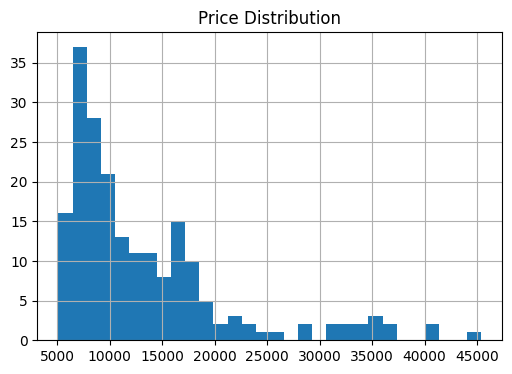

In [18]:
# histplot of price columns
dataset['price'].hist(bins=30, figsize=(6,4))
plt.title("Price Distribution")
plt.show()

## Histogram of numaric columns


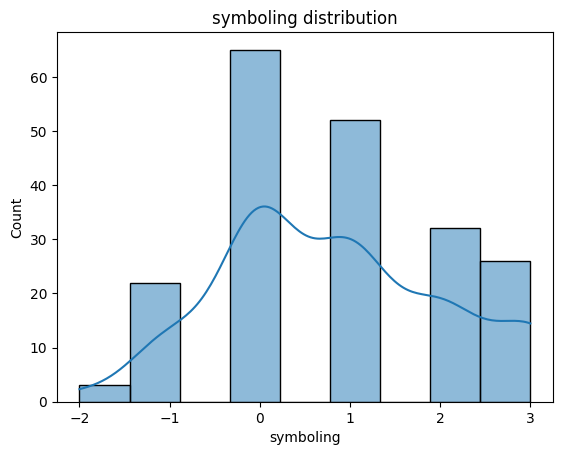

In [19]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['symboling'],kde=True)
plt.title('symboling distribution')
plt.show()

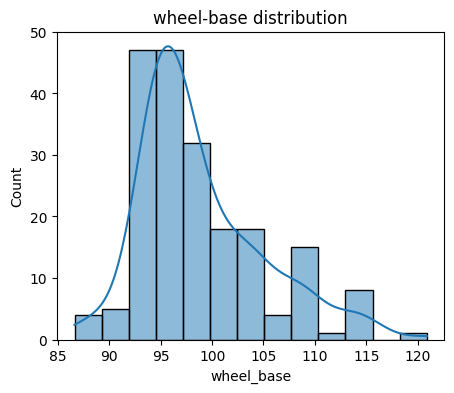

In [20]:
plt.figure(figsize=(5,4))
sns.histplot(dataset['wheel_base'],kde=True)
plt.title('wheel-base distribution')
plt.show()

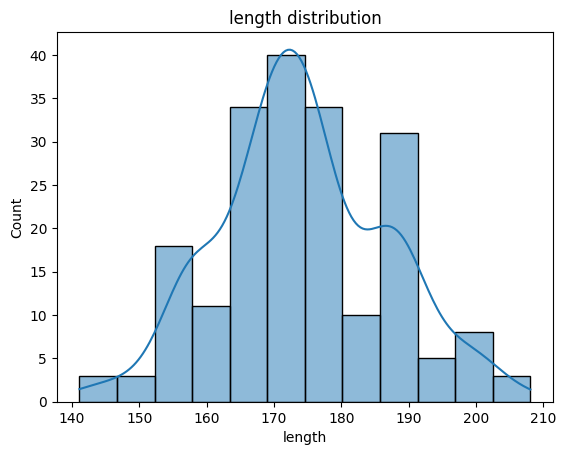

In [21]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['length'],kde=True)
plt.title('length distribution')
plt.show()

Insights : maximum length between the 150 to 180

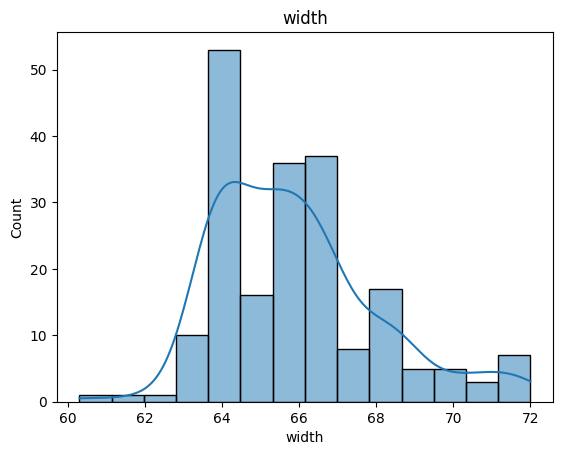

In [22]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['width'],kde=True)
plt.title('width')
plt.show()

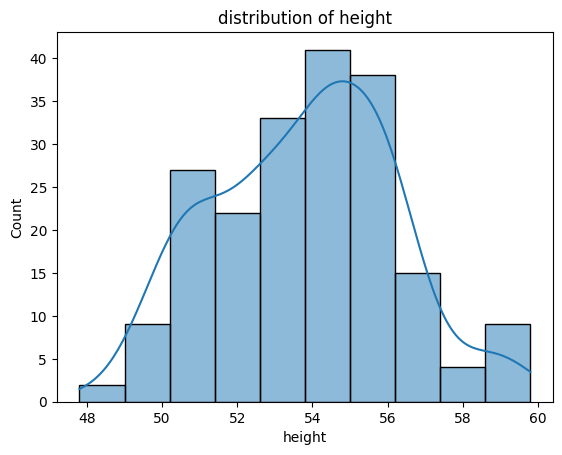

In [23]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['height'],kde=True)
plt.title('distribution of height')
plt.show()

Insights : maximu  height is 54 to 65 and lowest is 48

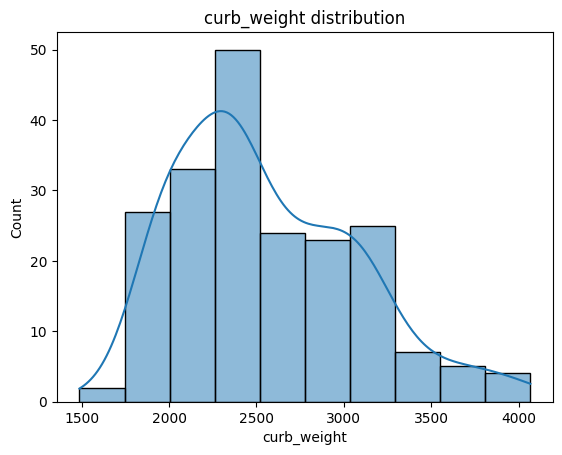

In [24]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['curb_weight'],kde=True)
plt.title('curb_weight distribution')
plt.show()

Insights : curn weight is between the 1500 to 4000 its values is high so its scale

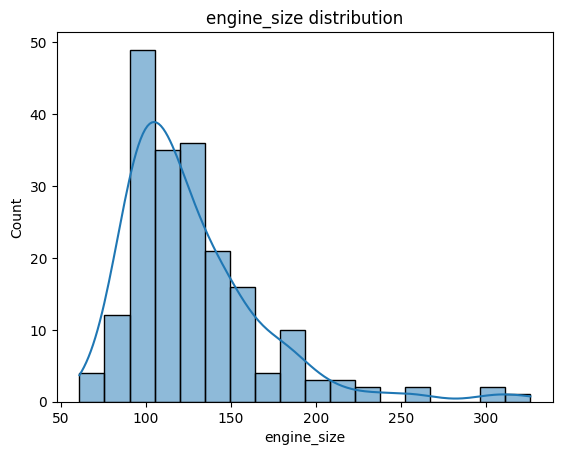

In [25]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['engine_size'],kde=True)
plt.title('engine_size distribution')
plt.show()

Insights : maximum engine size is 100

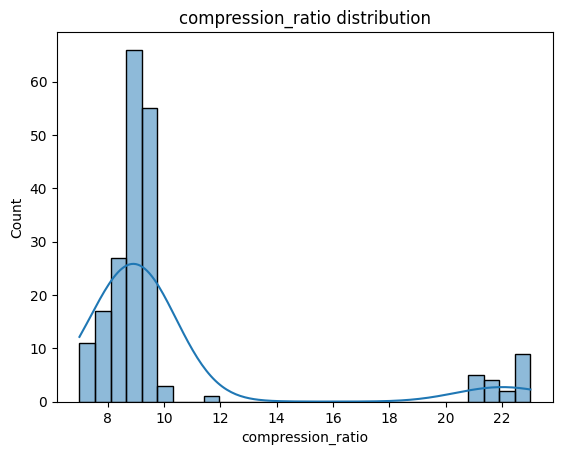

In [26]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['compression_ratio'],kde=True)
plt.title('compression_ratio distribution')
plt.show()

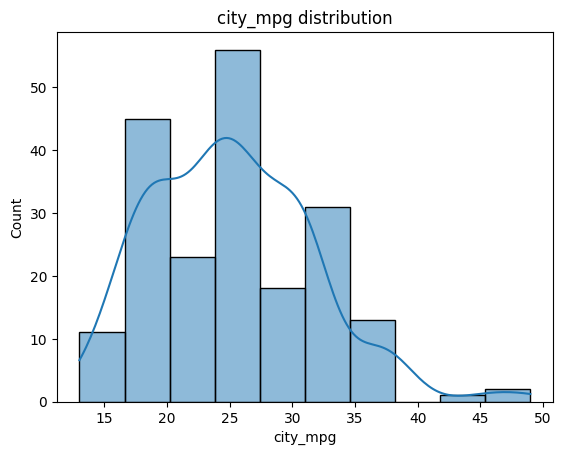

In [27]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['city_mpg'],kde=True)
plt.title('city_mpg distribution')
plt.show()

Insights : city mpg is 10 to 50

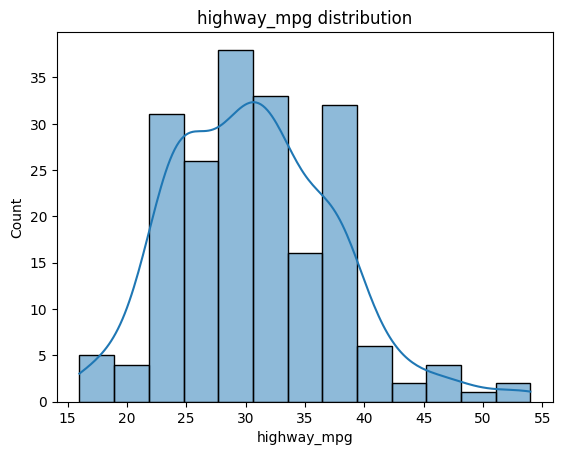

In [28]:
plt.Figure(figsize=(5,4))
sns.histplot(dataset['highway_mpg'],kde=True)
plt.title('highway_mpg distribution')
plt.show()

Insights : highway mpg is high compare to the city_mpg

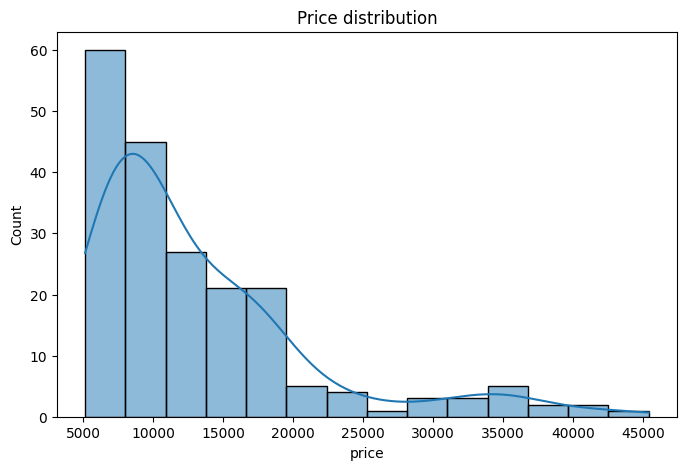

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(dataset["price"], kde=True)
plt.title("Price distribution")
plt.show()

Insights : range of price is 5000 to 45000

## Countplot of categorical columns

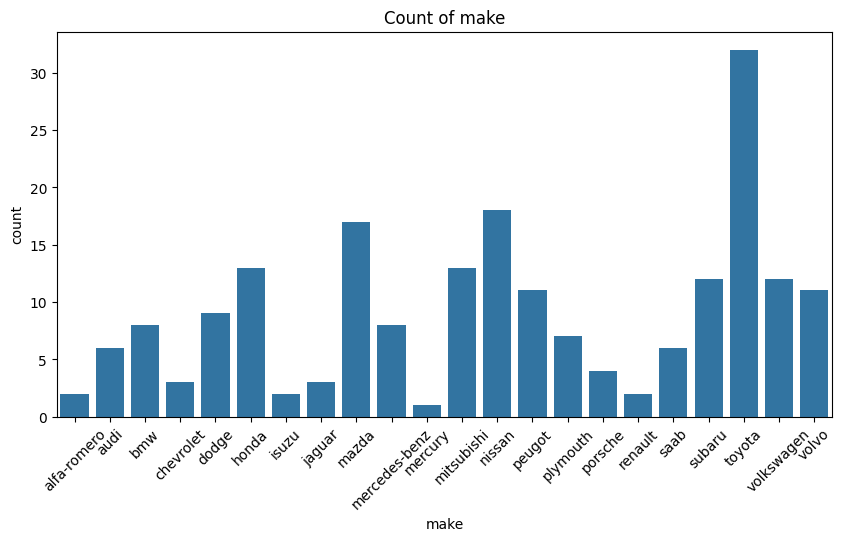

In [30]:
plt.figure(figsize=(10,5))
sns.countplot(data=dataset, x="make")
plt.title("Count of make")
plt.xticks(rotation=45)
plt.show()

Insights : in that columns give the company for car and here toyota cars are highest

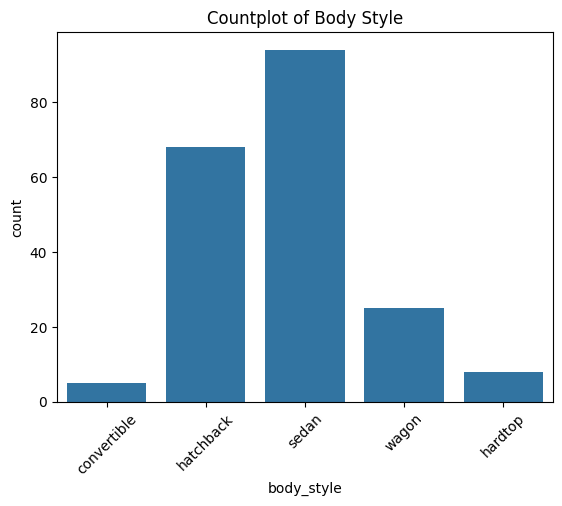

In [31]:
plt.Figure(figsize=(10,5))
sns.countplot(data=dataset, x="body_style")
plt.title("Countplot of Body Style")
plt.xticks(rotation=45)
plt.show()

Insights : in this dataset 5 type of body style and sedan style is high

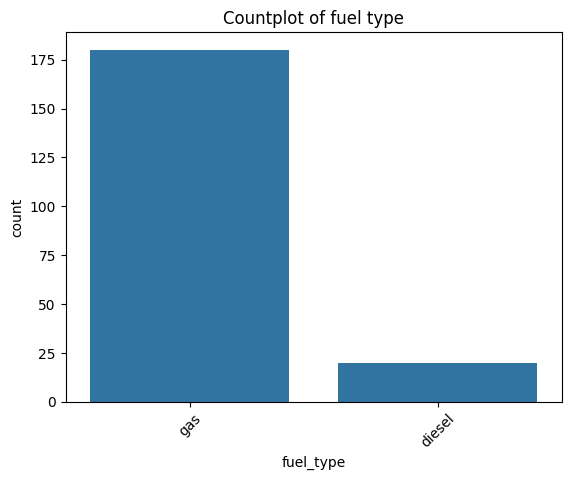

In [32]:
plt.Figure(figsize=(10,5))
sns.countplot(data=dataset, x="fuel_type")
plt.title("Countplot of fuel type")
plt.xticks(rotation=45)
plt.show()

Insights : in this dataset fuels type only 2 here not petrol car and gas type is high

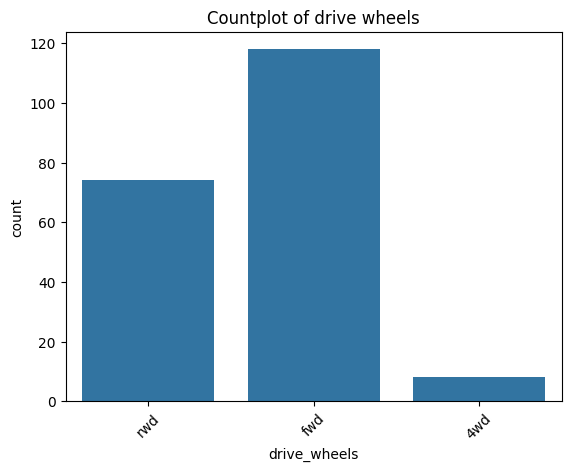

In [33]:
plt.Figure(figsize=(10,5))
sns.countplot(data=dataset, x="drive_wheels")
plt.title("Countplot of drive wheels")
plt.xticks(rotation=45)
plt.show()

Insights : give the rwd (Rear wheel drive), fwd (front wheel drive), 4wd (four wheel drive) and fwd is most demanded

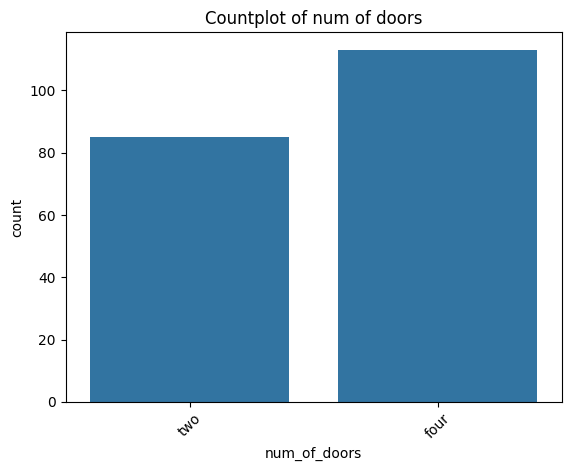

In [34]:
plt.Figure(figsize=(10,5))
sns.countplot(data=dataset, x="num_of_doors")
plt.title("Countplot of num of doors")
plt.xticks(rotation=45)
plt.show()

Insights : give the number of doors in cars. four door car demand is high

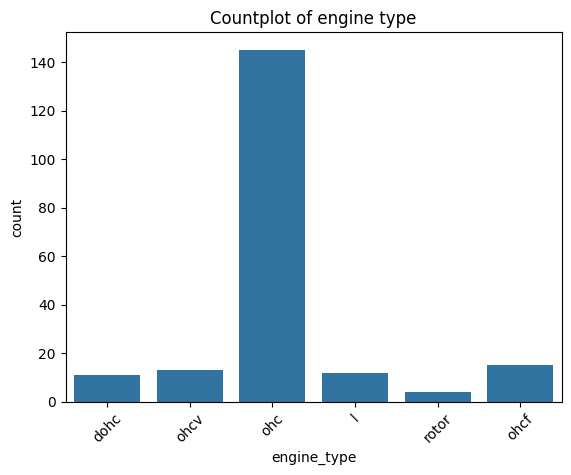

In [35]:
plt.Figure(figsize=(10,5))
sns.countplot(data=dataset, x="engine_type")
plt.title("Countplot of engine type")
plt.xticks(rotation=45)
plt.show()

Insights : in this dataset 6 types of engine and ohc is high

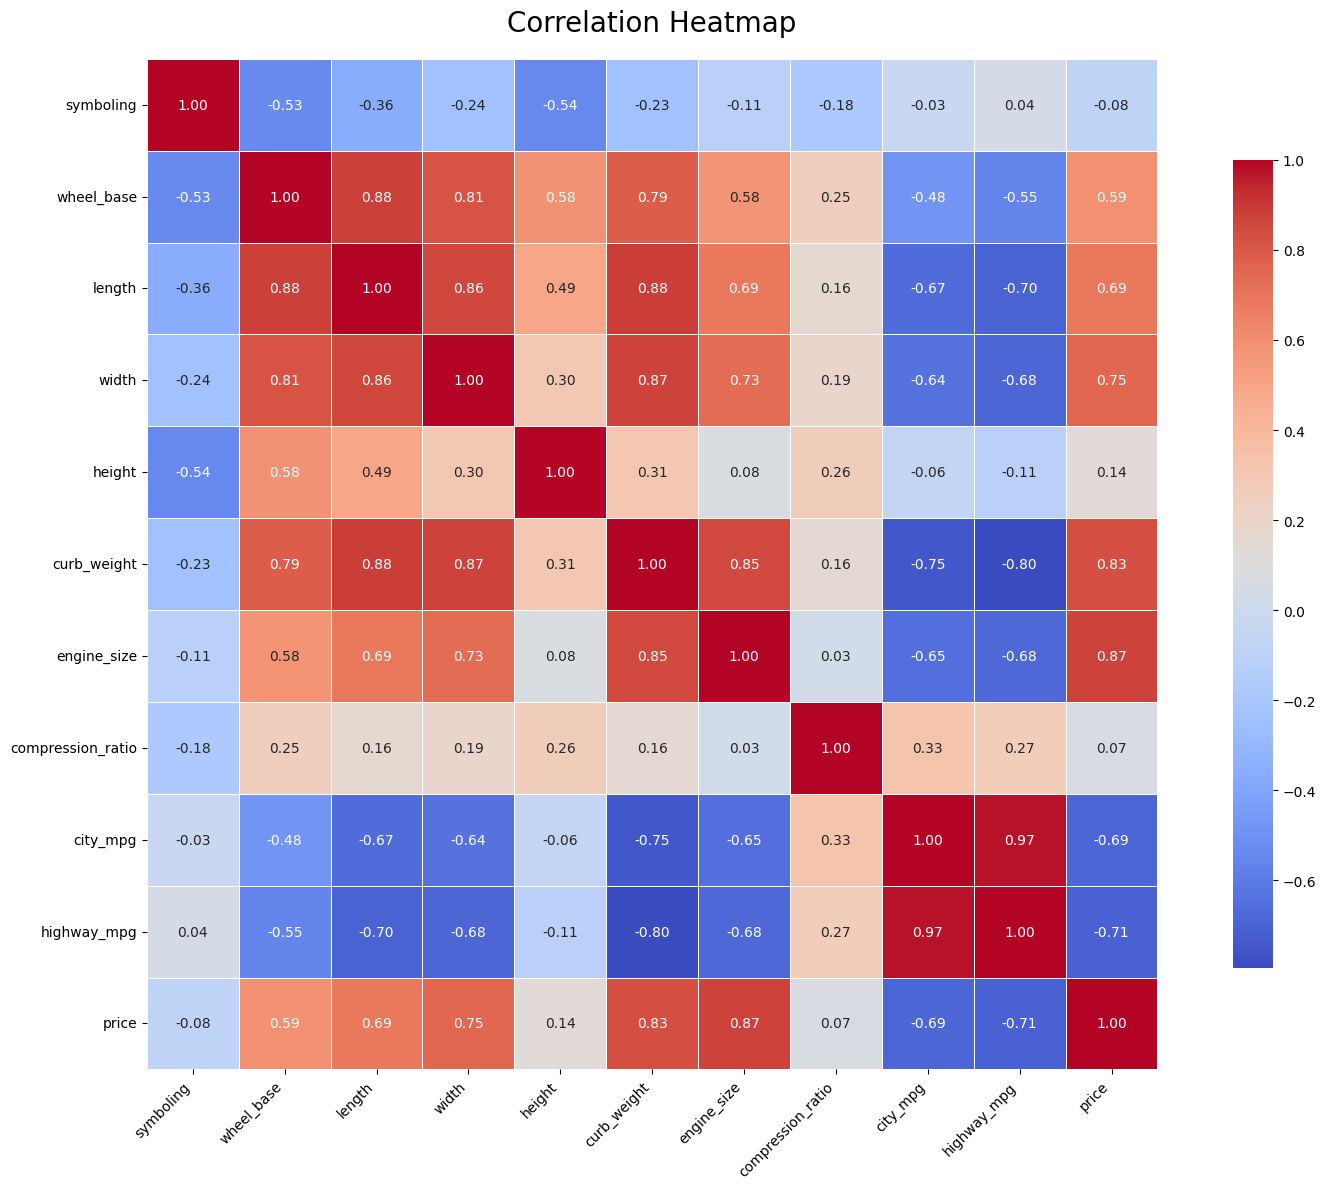

In [36]:
corr = dataset.select_dtypes(include='number').corr()

plt.figure(figsize=(16, 12))  # Best size for readability
sns.heatmap(
    corr,
    annot=True,           # Show correlation values
    fmt=".2f",            # Limit decimals
    cmap='coolwarm',      # Best color map for correlation
    linewidths=0.5,       # Thin lines between cells
    square=True,          # Make squares
    cbar_kws={"shrink": 0.8}  # Smaller color bar
)

plt.title("Correlation Heatmap", fontsize=20, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


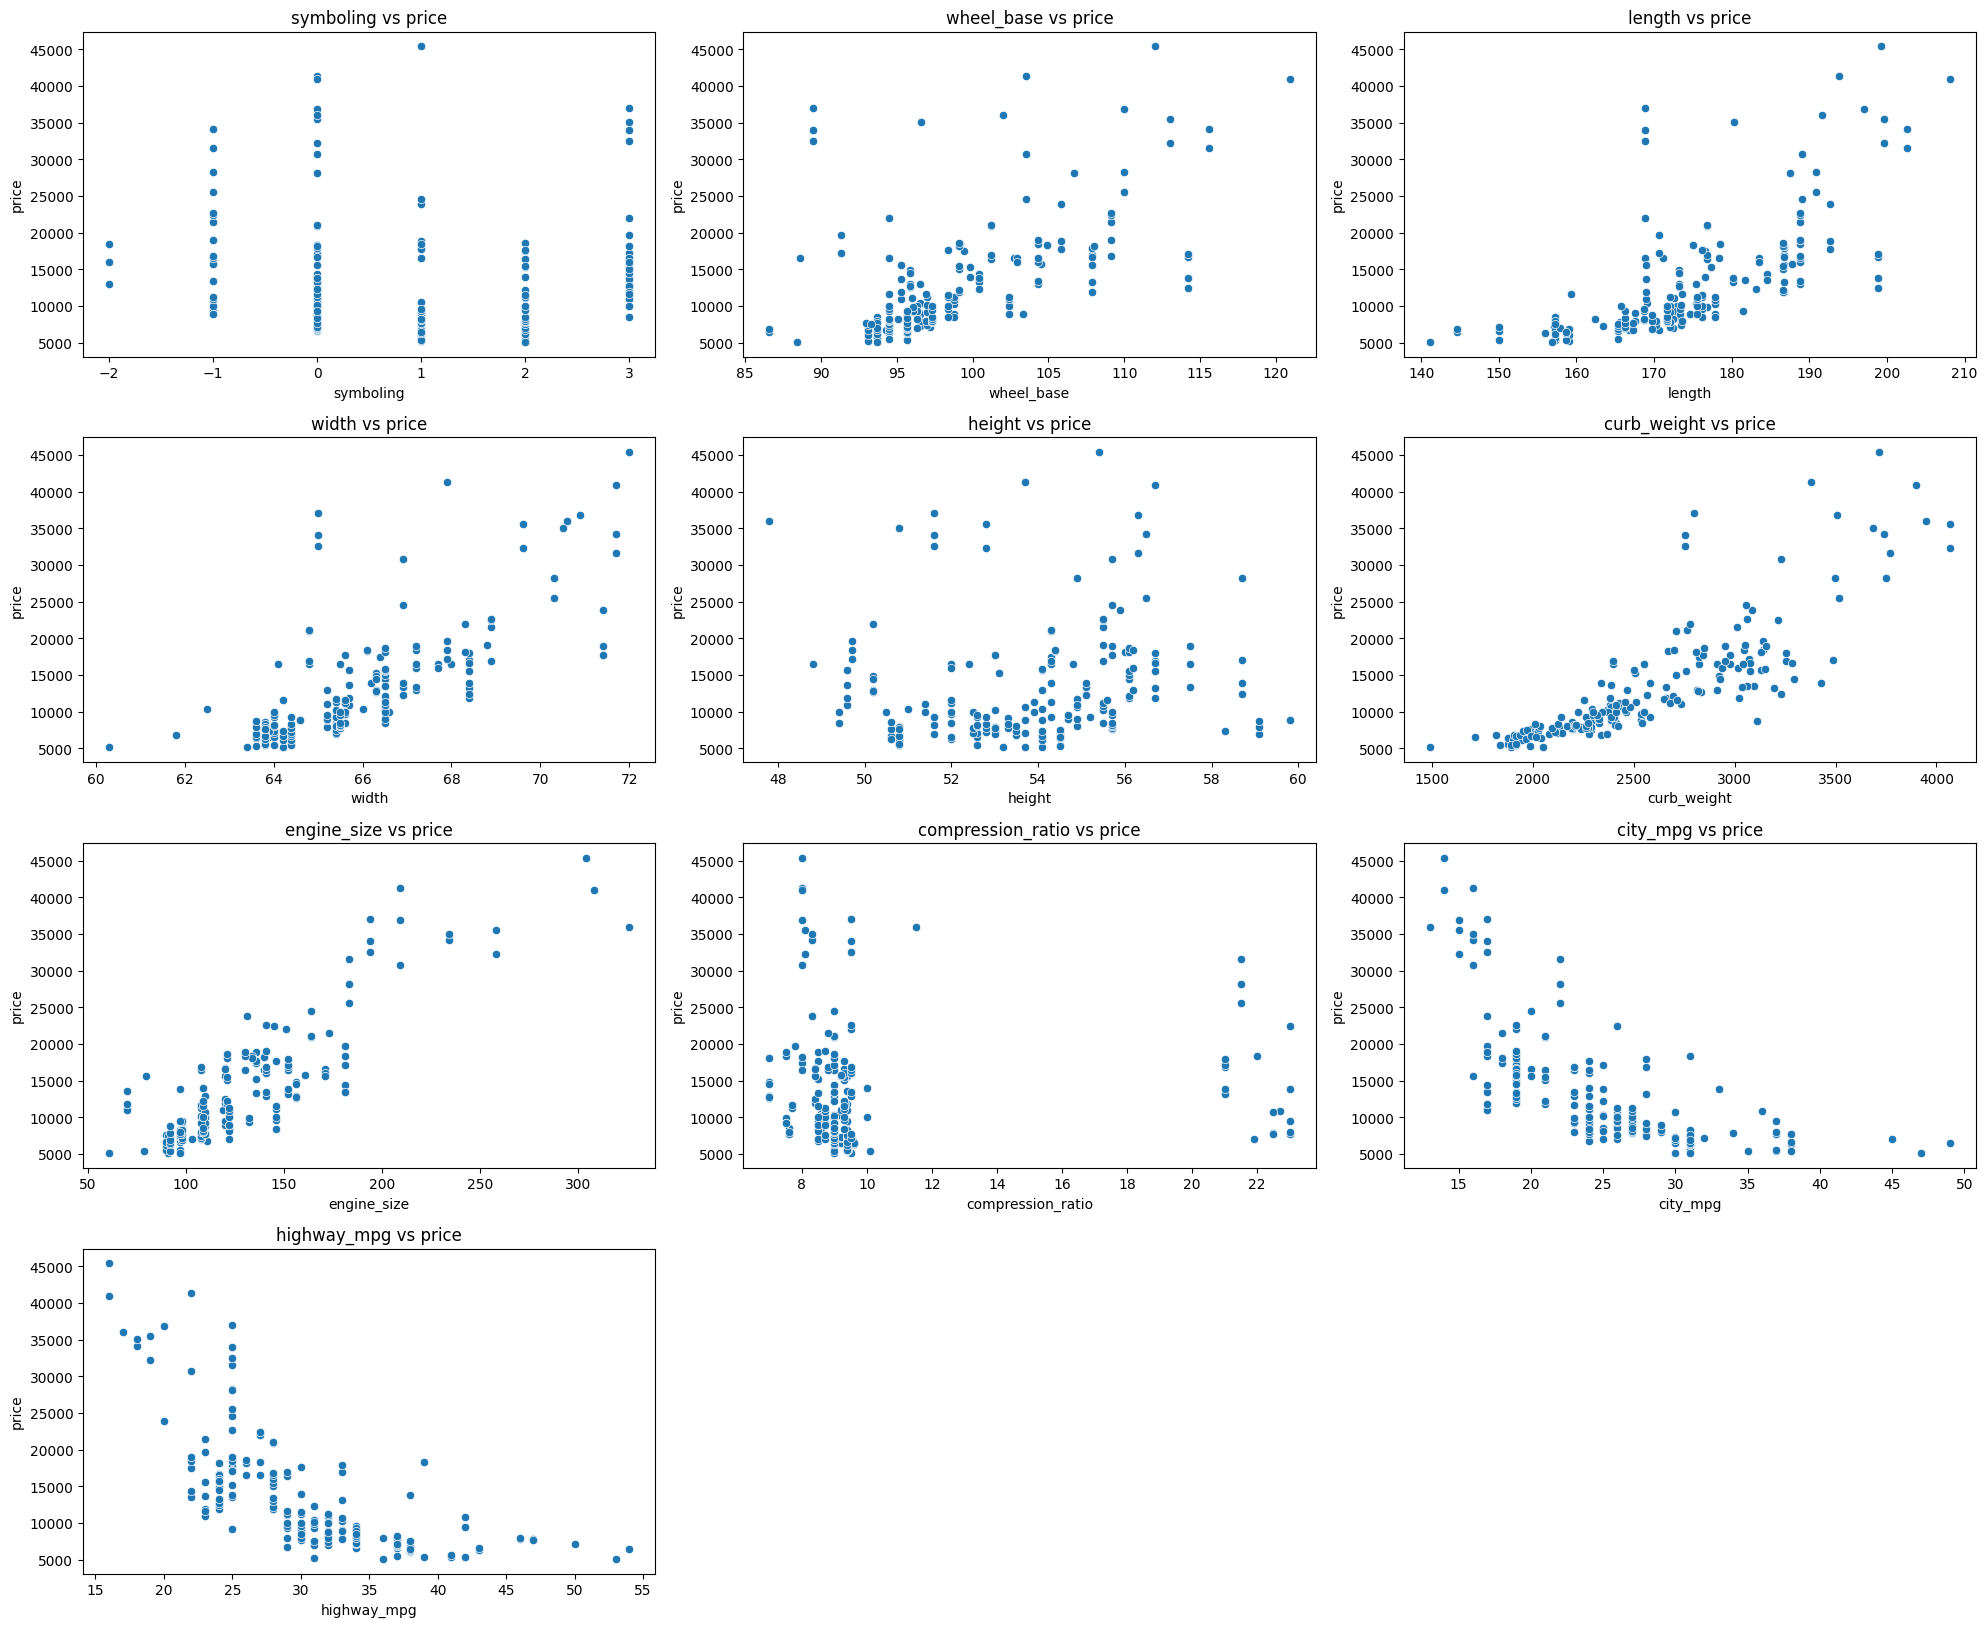

In [37]:
num = dataset.select_dtypes(include='number').columns

plt.figure(figsize=(20, 20))
plot_no = 1

for col in num:
    if col != 'price':
        plt.subplot(5, 3, plot_no)
        sns.scatterplot(data=dataset, x=col, y='price')
        plt.title(f'{col} vs price')
        plot_no += 1

plt.tight_layout()
plt.show()


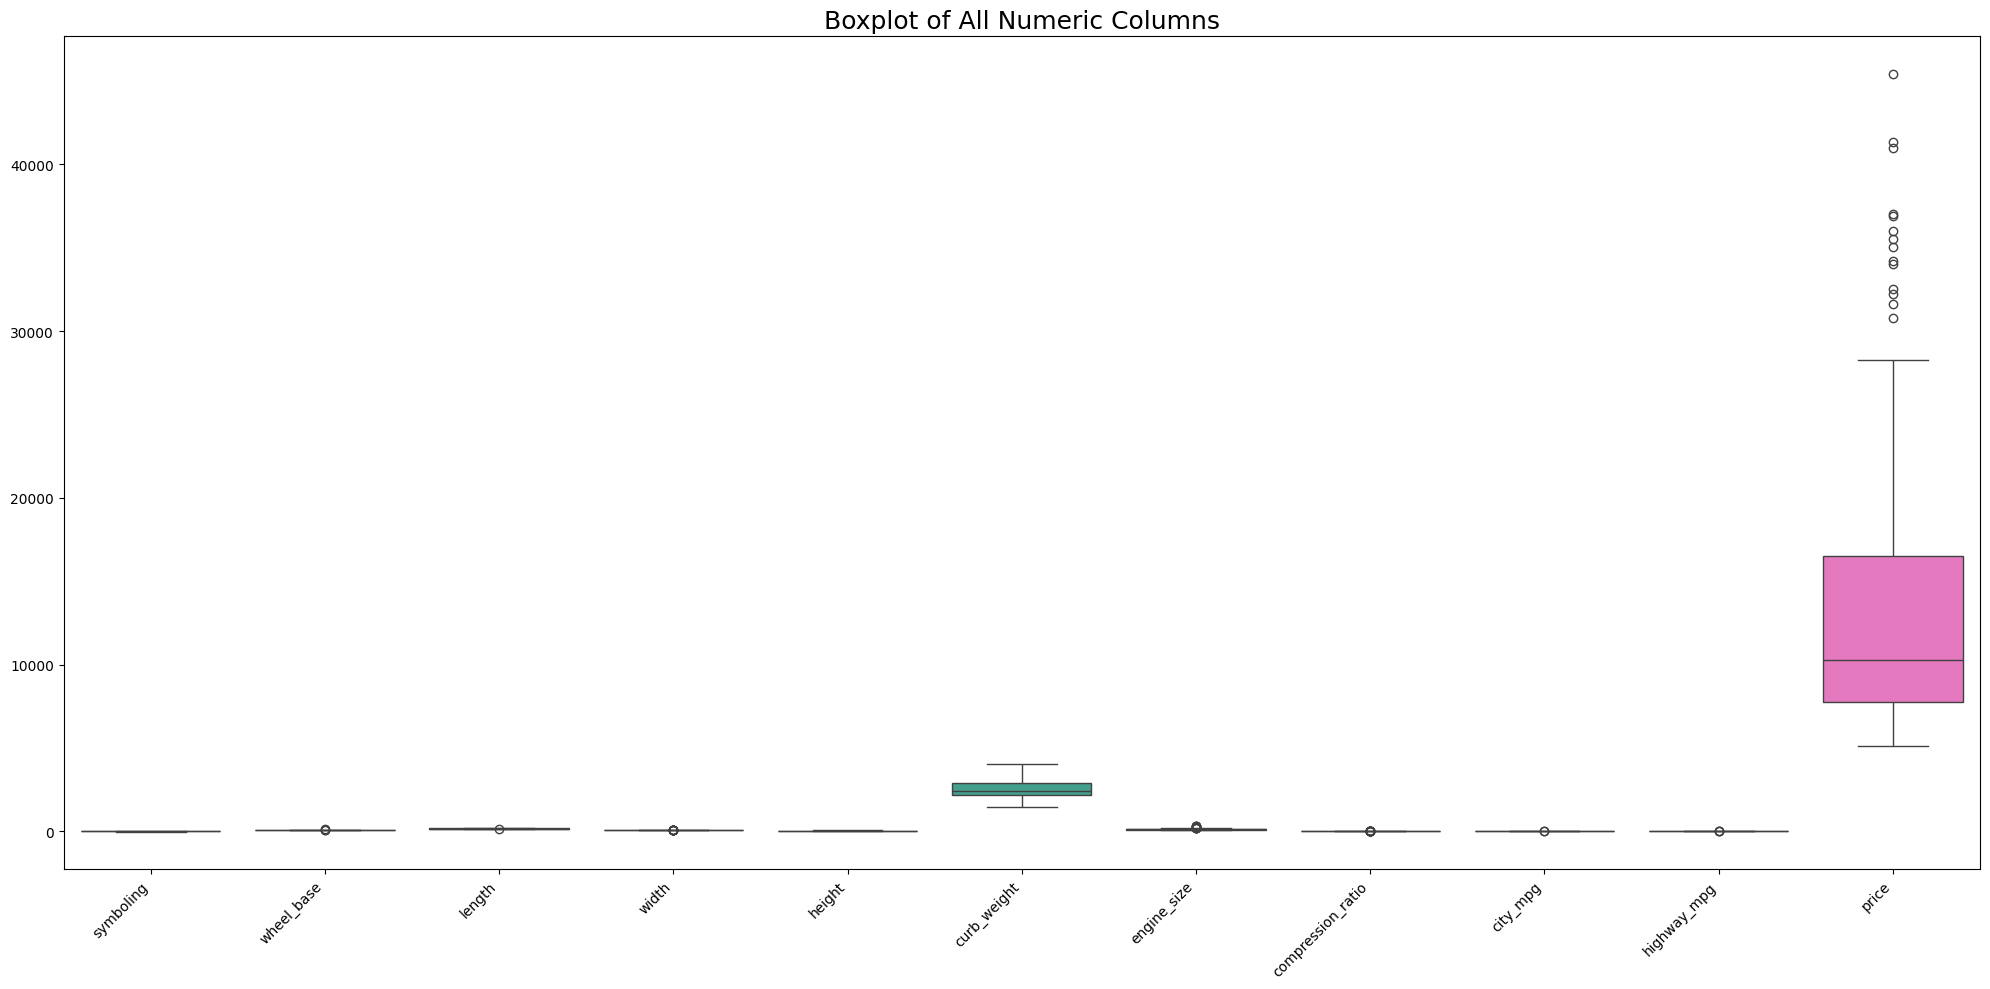

In [38]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=dataset.select_dtypes(include='number'), orient='v')
plt.title("Boxplot of All Numeric Columns", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Preprocessing

In [39]:
numeric_col = dataset.select_dtypes(include='number')

In [40]:
# Drop the columns that is high-corrilated
corr_metric = dataset.select_dtypes(include=['int','float']).corr().abs()
upper = corr_metric.where(np.triu(np.ones(corr_metric.shape),k=1).astype(bool))

#find the column with correlated > threshold
threshold = 0.90
to_drop = [col for col in upper.columns if any(upper[col]>threshold)]

print("To drop column:",to_drop)

#drop the columns
df = dataset.drop(columns=to_drop)

To drop column: ['highway_mpg']


In [41]:
num_cols = ['normalized_losses','bore','stroke','horsepower','peak_rpm','price']

for col in num_cols:
    dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

dataset.dtypes

symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_of_doors             str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_of_cylinders         str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                  int64
dtype: object

In [59]:
df.isnull().sum()

symboling             0
normalized_losses    36
make                  0
fuel_type             0
aspiration            0
num_of_doors          2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_of_cylinders      0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
price                 0
dtype: int64

In [43]:
# fil missing values using median and mode
for col in num_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())

cat_cols = dataset.select_dtypes(include='object').columns
for col in cat_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

In [44]:
# Split the data into X and y
X = dataset.drop("price", axis=1)
y = dataset["price"]


In [60]:
X.columns

Index(['symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
       'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
       'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_type',
       'num_of_cylinders', 'engine_size', 'fuel_system', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg'],
      dtype='str')

In [45]:
# Saprate the column numeric and categorical
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

numeric_features, categorical_features


(Index(['symboling', 'normalized_losses', 'wheel_base', 'length', 'width',
        'height', 'curb_weight', 'engine_size', 'bore', 'stroke',
        'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
        'highway_mpg'],
       dtype='str'),
 Index(['make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style',
        'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders',
        'fuel_system'],
       dtype='str'))

In [46]:
# Use standard scaler and encoder
preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


In [47]:
# train test and split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [61]:
X.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
1,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26
2,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30
3,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22
4,2,115.0,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25


**Decision Tree**

In [48]:
dt_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

**Random Forest Regressor**

In [49]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

**XGBoost Regressor**

In [50]:
from xgboost import XGBRegressor

xgb_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ))
])
xgb_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [55]:
# Evaluate the all model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    


In [56]:
# print the R2 score
print("\n🔹 Decision Tree Results")
evaluate_model(dt_model, X_test, y_test)

print("\n🔹 Random Forest Results")
evaluate_model(rf_model, X_test, y_test)

print("\n🔹XGBoost Results")
evaluate_model(xgb_model, X_test, y_test)


🔹 Decision Tree Results
R2 Score: 0.9069618912768816
MAE: 1913.025
RMSE: 3228.738612058895

🔹 Random Forest Results
R2 Score: 0.9672731410098973
MAE: 1396.4213404761902
RMSE: 1914.9375410511668

🔹XGBoost Results
R2 Score: 0.9666789770126343
MAE: 1343.7623291015625
RMSE: 1932.2432559074957


In [58]:
import joblib

joblib.dump(dt_model, "Price_model.pkl")
print("Model saved successfully")

Model saved successfully


## Conclusion

1. The relationship between car features and price is non-linear, making Linear Regression unsuitable.
2. Tree-based models, especially XGBoost, handle non-linearity, feature interactions, and outliers effectively.

Overall, this project highlights the importance of model selection, preprocessing, and tuning in solving real-world regression problems and provides a reliable approach for automobile price prediction.

## Thank You !